
**Logistic Regression Notebook**

In [142]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [143]:
df = pd.read_csv("FINAL_DS.csv")

df.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Consumer_Credit,Credit_Card_Lending
0,2008-01,2008,January,5.5000,2.2000,5.2000,65.6000,0.4000,33417,224159,71326,101598,54232
1,2008-02,2008,February,5.2500,2.5000,5.2000,65.0000,0.4000,31492,226772,71064,102081,54375
2,2008-03,2008,March,5.2500,2.5000,5.3000,64.5000,0.4000,32823,227769,60454,101945,54471
3,2008-04,2008,April,5.0000,3.0000,5.2000,64.7000,-0.5000,31895,233766,57134,101756,54404
4,2008-05,2008,May,5.0000,3.3000,5.4000,65.1000,-0.5000,32210,237820,40546,101556,55211


In [144]:
print(df["Bank_Rate"].describe())
print(df["CPI"].describe())
print(df["GDP_Growth"].describe())
print(df["Unemployment_Rate"].describe())

count   216.0000
mean      1.4565
std       1.7929
min       0.1000
25%       0.5000
50%       0.5000
75%       1.3125
max       5.5000
Name: Bank_Rate, dtype: float64
count   216.0000
mean      2.9935
std       2.3233
min      -0.1000
25%       1.7000
50%       2.6000
75%       3.5250
max      11.1000
Name: CPI, dtype: float64
count   216.0000
mean      0.3278
std       3.2790
min     -19.9000
25%       0.1000
50%       0.4000
75%       0.7000
max      17.0000
Name: GDP_Growth, dtype: float64
count   216.0000
mean      5.5403
std       1.5674
min       3.6000
25%       4.2000
50%       5.0000
75%       7.3250
max       8.5000
Name: Unemployment_Rate, dtype: float64


In [152]:
conditions = pd.DataFrame({
    "High_Bank_Rate": df["Bank_Rate"] > 5.25,
    "High_CPI": df["CPI"] > 3.525,
    "Negative_GDP": df["GDP_Growth"] < 0,
    "High_Unemployment": df["Unemployment_Rate"] > 7.325
})

df["Economy_Status"] = (
    conditions.sum(axis=1) >= 2
).astype(int)

In [153]:
df["Economy_Status"].value_counts()

Economy_Status
0    180
1     36
Name: count, dtype: int64

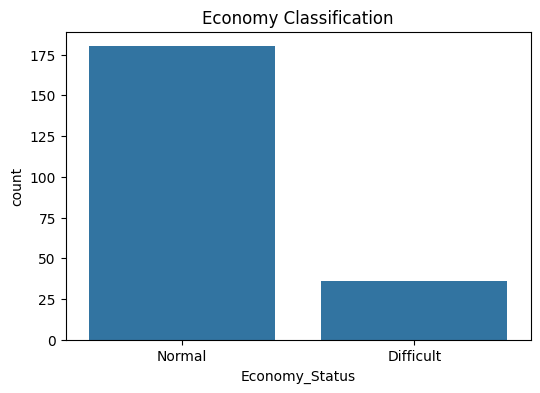

In [154]:
plt.figure(figsize=(6,4))

sns.countplot(x="Economy_Status", data=df)

plt.xticks([0,1],["Normal","Difficult"])

plt.title("Economy Classification")

plt.show()

In [155]:
X = df[
    [
        "Bank_Rate",
        "CPI",
        "Unemployment_Rate",
        "House_Price_Index",
        "GDP_Growth"
    ]
]

y = df["Economy_Status"]

In [156]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [157]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

print("Model Successfully Trained")

Model Successfully Trained


In [158]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [159]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :",accuracy)

Accuracy : 0.9090909090909091


In [160]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision :",precision)

Precision : 1.0


In [161]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall :",recall)

Recall : 0.42857142857142855


In [162]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC AUC :",auc)

ROC AUC : 0.8957528957528957


In [163]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[37,  0],
       [ 4,  3]], dtype=int64)

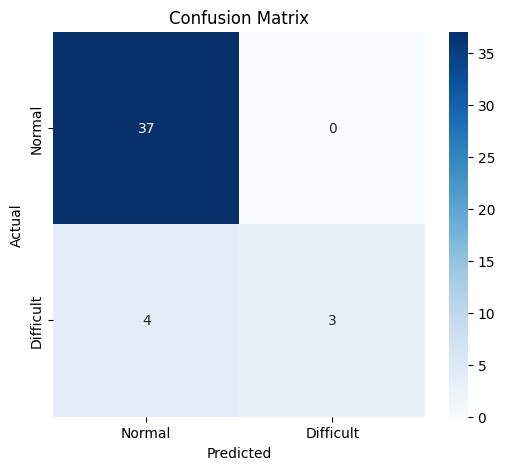

In [164]:
plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Normal","Difficult"],

    yticklabels=["Normal","Difficult"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [165]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        37
           1       1.00      0.43      0.60         7

    accuracy                           0.91        44
   macro avg       0.95      0.71      0.77        44
weighted avg       0.92      0.91      0.89        44



In [166]:
import joblib

joblib.dump(
    logistic_model,
    "../synthetic_bank/models/economic_regime_logistic.pkl"
)

joblib.dump(
    logistic_scaler,
    "../synthetic_bank/models/economic_regime_scaler.pkl"
)

joblib.dump(
    logistic_features,
    "../synthetic_bank/models/economic_regime_features.pkl"
)

print("Economic Regime Logistic Regression model saved successfully.")

Economic Regime Logistic Regression model saved successfully.
